# Theoretical Analysis Experiments for DNA-GRU Transactions Paper

**Assumes training is already complete and weights exist.**

Results are saved under `./Experiments/{DATASET_NAME}_v4/TheoryAnalysis/` with subfolders:
- `Results/` — CSV files
- `MatFiles/` — `.mat` files for MATLAB plotting
- `Figures/` — PNG figures


## Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import os
import numpy as np
from tqdm.notebook import tqdm
import random
import time
import pandas as pd
import math
from collections import defaultdict
import json
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
    'xtick.labelsize': 10, 'ytick.labelsize': 10, 'legend.fontsize': 10,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif',
})


## Configuration
**Change `DATASET_NAME` and GPU below.**

In [2]:
DATASET_NAME = "Erlich"   # <-- CHANGE PER DATASET

os.environ["CUDA_VISIBLE_DEVICES"] = "3"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE == "cuda" else ""))

REAL_DATA_DIR = Path("../Data")

DATASET_CONFIGS = {
    "Erlich":                      {"label_len": 152, "index_length": 16, "max_deviation": 10, "filter_index": False, "target_failure": 0.02},
    "Grass":                       {"label_len": 117, "index_length": 13, "max_deviation": 11, "filter_index": False, "target_failure": 0.66},
    "Organick":                    {"label_len": 110, "index_length": 33, "max_deviation": 5,  "filter_index": False, "target_failure": 0.17},
    "Srinivasavaradhan":           {"label_len": 110, "index_length": 4,  "max_deviation": 10, "filter_index": False, "target_failure": 14.58},
    "BinnedTestIllumina":          {"label_len": 128, "index_length": 12, "max_deviation": 4,  "filter_index": True,  "target_failure": 0.0055},
    "BinnedNanoporeFirstFlowcell": {"label_len": 128, "index_length": 12, "max_deviation": 4,  "filter_index": True,  "target_failure": 3.88},
    "BinnedNanoporeTwoFlowcells":  {"label_len": 128, "index_length": 12, "max_deviation": 4,  "filter_index": True,  "target_failure": 1.65},
}
DATASET_FILES = {
    "Erlich": "Erlich.txt", "Grass": "Grass.txt", "Srinivasavaradhan": "Srinivasavaradhan.txt",
    "BinnedTestIllumina": "BinnedTestIllumina.txt",
    "BinnedNanoporeFirstFlowcell": "BinnedNanoporeFirstFlowcell.txt",
    "BinnedNanoporeTwoFlowcells": "BinnedNanoporeTwoFlowcells.txt",
}

CONFIG = DATASET_CONFIGS[DATASET_NAME]
LABEL_SEQ_LEN  = CONFIG["label_len"]
INDEX_LENGTH   = CONFIG["index_length"]
MAX_DEVIATION  = CONFIG["max_deviation"]
FILTER_INDEX   = CONFIG["filter_index"]
MAX_CLUSTER_SIZE = 16
ORIGINAL_SEQ_LEN = LABEL_SEQ_LEN + INDEX_LENGTH if FILTER_INDEX else LABEL_SEQ_LEN
MAX_READ_LEN = ORIGINAL_SEQ_LEN + MAX_DEVIATION + 8

EMBED_DIM, ALIGNMENT_FILTERS, EMBEDDING_FILTERS = 300, 128, 500
GRU_HIDDEN, GRU_LAYERS, DROPOUT = 300, 2, 0.1
BATCH_SIZE = 200
VOCAB = {'N': 0, 'A': 1, 'C': 2, 'G': 3, 'T': 4}
PADDING_IDX = 0; VOCAB_SIZE = 5
INT_TO_CHAR = {v: k for k, v in VOCAB.items()}

# ── Paths ──
EXPERIMENT_DIR = Path(f"./Experiments/{DATASET_NAME}_v4")
WEIGHTS_DIR    = EXPERIMENT_DIR / "Models"
MODEL_PATH     = WEIGHTS_DIR / f"best_model_{DATASET_NAME}.pth"
EVAL_FILE      = REAL_DATA_DIR / DATASET_FILES[DATASET_NAME]

# Theory analysis outputs — subfolder of same experiment directory
THEORY_DIR   = EXPERIMENT_DIR / "TheoryAnalysis"
T_RESULTS    = THEORY_DIR / "Results"
T_MAT        = THEORY_DIR / "MatFiles"
T_FIGURES    = THEORY_DIR / "Figures"
for d in [T_RESULTS, T_MAT, T_FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"\nDataset:  {DATASET_NAME}")
print(f"Model:    {MODEL_PATH}")
print(f"Data:     {EVAL_FILE}")
print(f"Output:   {THEORY_DIR}")
assert MODEL_PATH.exists(), f"Model not found: {MODEL_PATH}"
assert EVAL_FILE.exists(),  f"Eval file not found: {EVAL_FILE}"


Device: cuda (NVIDIA GeForce RTX 3080)

Dataset:  Erlich
Model:    Experiments/Erlich_v4/Models/best_model_Erlich.pth
Data:     ../Data/Erlich.txt
Output:   Experiments/Erlich_v4/TheoryAnalysis


## Model & Dataset Classes
*Identical to `DNA-GRU-CPL-MultiThreshold` code.*

In [3]:
def encode_seq(seq, char_to_int, max_len, padding_idx):
    encoded = [char_to_int.get(c, padding_idx) for c in seq]
    encoded = encoded[:max_len]
    return encoded + [padding_idx] * (max_len - len(encoded))

def decode_seq(tensor, int_to_char):
    if hasattr(tensor, 'is_cuda') and tensor.is_cuda:
        tensor = tensor.cpu()
    ints = tensor.numpy().tolist() if hasattr(tensor, 'numpy') else list(tensor)
    try:
        first_pad = ints.index(PADDING_IDX)
        ints = ints[:first_pad]
    except ValueError:
        pass
    return "".join([int_to_char.get(i, '?') for i in ints])


class DnaClusterDataset(Dataset):
    def __init__(self, filepath, max_cluster_size, max_read_len, label_seq_len,
                 char_to_int, padding_idx):
        self.max_cluster_size = max_cluster_size
        self.max_read_len = max_read_len
        self.label_seq_len = label_seq_len
        self.char_to_int = char_to_int
        self.padding_idx = padding_idx
        self.labels = []
        self.clusters = []
        self._load_data(filepath)

    def _load_data(self, filepath):
        print(f"Loading data from {filepath}...")
        with open(filepath, 'r') as f:
            content = f.read()
        blocks = content.split('\n\n')
        for block in blocks:
            if not block.strip(): continue
            lines = [l.strip() for l in block.strip().split('\n')]
            if len(lines) < 3: continue
            label_seq = lines[0]
            reads = [r for r in lines[2:] if r]
            if not reads or not label_seq: continue
            self.labels.append(label_seq)
            self.clusters.append(reads)
        print(f"Loaded {len(self.labels)} clusters.")

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        label_str = self.labels[idx]
        reads = list(self.clusters[idx])
        label_t = torch.tensor(
            encode_seq(label_str, self.char_to_int, self.label_seq_len, self.padding_idx),
            dtype=torch.long)
        cluster_t = torch.full((self.max_cluster_size, self.max_read_len),
                               self.padding_idx, dtype=torch.long)
        random.shuffle(reads)
        for i, r in enumerate(reads[:self.max_cluster_size]):
            cluster_t[i] = torch.tensor(
                encode_seq(r, self.char_to_int, self.max_read_len, self.padding_idx),
                dtype=torch.long)
        return cluster_t, label_t

    def get_raw_reads(self, idx): return self.clusters[idx]
    def get_raw_label(self, idx): return self.labels[idx]
    def get_cluster_size(self, idx): return len(self.clusters[idx])


# ── Model classes: EXACT copies from DNA-GRU-CPL-MultiThreshold ──

class DepthwiseSeparableConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding=0):
        super().__init__()
        self.depthwise = nn.Conv1d(in_channels, in_channels, kernel_size=kernel_size,
                                   padding=padding, groups=in_channels)
        self.pointwise = nn.Conv1d(in_channels, out_channels, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))

class MultiKernelConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, seq_len, dropout=0.1):
        super().__init__()
        c1 = out_channels // 3
        c2 = out_channels // 3
        c3 = out_channels - c1 - c2
        self.conv1 = DepthwiseSeparableConv1d(in_channels, c1, kernel_size=1)
        self.conv3 = DepthwiseSeparableConv1d(in_channels, c2, kernel_size=3, padding=1)
        self.conv5 = DepthwiseSeparableConv1d(in_channels, c3, kernel_size=5, padding=2)
        self.norm1 = nn.LayerNorm([c1, seq_len])
        self.norm2 = nn.LayerNorm([c2, seq_len])
        self.norm3 = nn.LayerNorm([c3, seq_len])
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        x1 = F.gelu(self.norm1(self.conv1(x)))
        x2 = F.gelu(self.norm2(self.conv3(x)))
        x3 = F.gelu(self.norm3(self.conv5(x)))
        return self.dropout(torch.cat([x1, x2, x3], dim=1))

class AlignmentModule(nn.Module):
    def __init__(self, embed_dim, out_channels, seq_len, dropout=0.1):
        super().__init__()
        self.conv_block1 = MultiKernelConvBlock(embed_dim, out_channels, seq_len, dropout)
        self.conv_block2 = MultiKernelConvBlock(out_channels, out_channels, seq_len, dropout)
    def forward(self, x):
        batch, cluster, emb, seq = x.shape
        x = x.view(batch * cluster, emb, seq)
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        return x.view(batch, cluster, -1, seq)

class EmbeddingModule(nn.Module):
    def __init__(self, in_channels, out_channels, in_len, out_len, dropout=0.1):
        super().__init__()
        self.conv_block = MultiKernelConvBlock(in_channels, out_channels, in_len, dropout)
        self.linear = nn.Linear(in_len, out_len)
    def forward(self, x):
        x = self.conv_block(x)
        batch, channels, seq_len = x.shape
        x = x.reshape(batch * channels, seq_len)
        x = self.linear(x)
        return x.reshape(batch, channels, -1)

class ImprovedDNAReconstructionModel(nn.Module):
    def __init__(self, vocab_size, label_seq_len, max_read_len, padding_idx,
                 embed_dim=128, alignment_filters=128, embedding_filters=256,
                 gru_hidden=256, gru_layers=2, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.alignment = AlignmentModule(embed_dim, alignment_filters, max_read_len, dropout)
        self.embedding_module = EmbeddingModule(
            alignment_filters, embedding_filters, max_read_len, label_seq_len, dropout)
        self.gru = nn.GRU(embedding_filters, gru_hidden, num_layers=gru_layers,
                          batch_first=True, bidirectional=True,
                          dropout=dropout if gru_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc_out = nn.Linear(gru_hidden * 2, vocab_size)

    def forward(self, cluster_batch, return_probs=False):
        emb = self.embedding(cluster_batch).permute(0, 1, 3, 2)
        aligned = self.alignment(emb)
        nci = torch.sum(aligned, dim=1)
        feats = self.embedding_module(nci).permute(0, 2, 1)
        gru_out, _ = self.gru(feats)
        logits = self.fc_out(self.dropout(gru_out))
        if return_probs:
            return logits, F.softmax(logits, dim=2)
        return logits

    def forward_with_intermediates(self, cluster_batch):
        """Forward pass returning intermediate representations for analysis."""
        emb = self.embedding(cluster_batch).permute(0, 1, 3, 2)
        aligned = self.alignment(emb)
        nci = torch.sum(aligned, dim=1)
        feats = self.embedding_module(nci)
        feats_t = feats.permute(0, 2, 1)
        gru_out, _ = self.gru(feats_t)
        logits = self.fc_out(self.dropout(gru_out))
        return {'nci': nci, 'feats': feats, 'gru_out': gru_out, 'logits': logits}


def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]: dp[i][j] = dp[i-1][j-1]
            else: dp[i][j] = 1 + min(dp[i-1][j-1], dp[i-1][j], dp[i][j-1])
    return dp[m][n]

print("Model and dataset classes defined.")

Model and dataset classes defined.


## Load Model & Data

In [4]:
model = ImprovedDNAReconstructionModel(
    VOCAB_SIZE, LABEL_SEQ_LEN, MAX_READ_LEN, PADDING_IDX,
    EMBED_DIM, ALIGNMENT_FILTERS, EMBEDDING_FILTERS,
    GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(DEVICE)
model.load_state_dict(torch.load(str(MODEL_PATH), map_location=DEVICE, weights_only=True))
model.eval()
print(f"Model: {sum(p.numel() for p in model.parameters()):,} params from {MODEL_PATH.name}")

test_ds = DnaClusterDataset(EVAL_FILE, MAX_CLUSTER_SIZE, MAX_READ_LEN, LABEL_SEQ_LEN, VOCAB, PADDING_IDX)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


/homes/shubham/anaconda3/envs/pytorchenv/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Model: 3,480,949 params from best_model_Erlich.pth
Loading data from ../Data/Erlich.txt...
Loaded 72000 clusters.


## Experiment 0: Baseline DNN-only Evaluation

In [5]:
all_preds, all_probs, all_labels = [], [], []
with torch.no_grad():
    for clusters, labels in tqdm(test_loader, desc="DNN Inference"):
        logits, probs = model(clusters.to(DEVICE), return_probs=True)
        preds = logits.argmax(dim=2).cpu(); probs_cpu = probs.cpu()
        for i in range(labels.shape[0]):
            all_preds.append(preds[i]); all_probs.append(probs_cpu[i]); all_labels.append(labels[i])

N = len(all_preds)
dnn_failures = [i for i in range(N) if decode_seq(all_preds[i], INT_TO_CHAR) != decode_seq(all_labels[i], INT_TO_CHAR)]
dnn_rate = len(dnn_failures) / N * 100
print(f"Total: {N:,} | DNN failures: {len(dnn_failures):,} ({dnn_rate:.4f}%) | Target: {CONFIG['target_failure']}%")


DNN Inference:   0%|          | 0/360 [00:00<?, ?it/s]

Total: 72,000 | DNN failures: 17 (0.0236%) | Target: 0.02%


## Experiment 1: Effective Context Radius (Gradient Attribution)
Measures influence radius of each output position at the embedding→BiGRU boundary.

In [6]:
NUM_GRAD_SAMPLES = min(200, N)
grad_indices = random.sample(range(N), NUM_GRAD_SAMPLES)
target_positions = list(range(0, LABEL_SEQ_LEN, max(1, LABEL_SEQ_LEN // 16)))

influence_matrix = np.zeros((LABEL_SEQ_LEN, LABEL_SEQ_LEN), dtype=np.float64)

# ── Build a SEPARATE model for gradient analysis ──
# This ensures the original `model` object and saved weights are never touched.
grad_model = ImprovedDNAReconstructionModel(
    VOCAB_SIZE, LABEL_SEQ_LEN, MAX_READ_LEN, PADDING_IDX,
    EMBED_DIM, ALIGNMENT_FILTERS, EMBEDDING_FILTERS,
    GRU_HIDDEN, GRU_LAYERS, DROPOUT).to(DEVICE)
grad_model.load_state_dict(torch.load(str(MODEL_PATH), map_location=DEVICE, weights_only=True))
grad_model.eval()
# cuDNN RNN backward requires train mode on the GRU submodule only
grad_model.gru.train()
grad_model.dropout.eval()
# Freeze all parameters — no weight updates possible even by accident
for p in grad_model.parameters():
    p.requires_grad_(False)

print(f"Gradient attribution: {NUM_GRAD_SAMPLES} samples × {len(target_positions)} positions...")
print(f"(Using separate model copy — original weights untouched)")

for si in tqdm(grad_indices, desc="Gradient Attribution"):
    cluster, _ = test_ds[si]
    cluster = cluster.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        emb = grad_model.embedding(cluster).permute(0,1,3,2)
        nci = torch.sum(grad_model.alignment(emb), dim=1)

    # Detach here: feats is the only tensor requiring grad
    feats = grad_model.embedding_module(nci).detach().requires_grad_(True)
    gru_out, _ = grad_model.gru(feats.permute(0,2,1))
    logits = grad_model.fc_out(grad_model.dropout(gru_out))

    for tp in target_positions:
        if feats.grad is not None: feats.grad.zero_()
        logits[0, tp, :].max().backward(retain_graph=True)
        if feats.grad is not None:
            gn = feats.grad[0].norm(dim=0).detach().cpu().numpy()
            s = gn.sum()
            if s > 0: influence_matrix[tp, :] += gn / s

    del feats, gru_out, logits
    torch.cuda.empty_cache()

# Free the gradient model
del grad_model
torch.cuda.empty_cache()
print("Gradient model freed. Original model unchanged.")

# Normalize
for tp in target_positions:
    if NUM_GRAD_SAMPLES > 0: influence_matrix[tp, :] /= NUM_GRAD_SAMPLES

# Compute effective context radii
context_radii = {50: [], 75: [], 90: [], 95: [], 99: []}
for tp in target_positions:
    row = influence_matrix[tp, :]
    s = row.sum()
    if s == 0: continue
    rn = row / s
    for pct, lst in context_radii.items():
        for w in range(1, LABEL_SEQ_LEN):
            if rn[max(0,tp-w):min(LABEL_SEQ_LEN,tp+w+1)].sum() >= pct/100:
                lst.append(w); break
        else: lst.append(LABEL_SEQ_LEN)

print("\nEffective Context Radius:")
cr_summary = {}
for pct, radii in context_radii.items():
    if not radii: continue
    m, md, mx = np.mean(radii), np.median(radii), np.max(radii)
    print(f"  {pct}% influence within radius: mean={m:.1f}, median={md:.1f}, max={mx}")
    cr_summary[f"pct{pct}"] = {"mean": float(m), "median": float(md), "max": int(mx)}

np.save(T_RESULTS / "influence_matrix.npy", influence_matrix)
with open(T_RESULTS / "context_radius.json", 'w') as f: json.dump(cr_summary, f, indent=2)
sio.savemat(str(T_MAT / f'theory_context_radius_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME,
    'influence_matrix': influence_matrix,
    'target_positions': np.array(target_positions, dtype=np.float64),
    'label_seq_len': np.float64(LABEL_SEQ_LEN),
    **{f'radius_{p}pct_values': np.array(v, dtype=np.float64) for p, v in context_radii.items() if v},
})
print(f"\n→ Saved to {T_RESULTS} and {T_MAT}")

Gradient attribution: 200 samples × 17 positions...
(Using separate model copy — original weights untouched)


Gradient Attribution:   0%|          | 0/200 [00:00<?, ?it/s]

Gradient model freed. Original model unchanged.

Effective Context Radius:
  50% influence within radius: mean=1.1, median=1.0, max=2
  75% influence within radius: mean=2.1, median=2.0, max=3
  90% influence within radius: mean=4.8, median=5.0, max=5
  95% influence within radius: mean=8.2, median=9.0, max=9
  99% influence within radius: mean=18.5, median=20.0, max=21

→ Saved to Experiments/Erlich_v4/TheoryAnalysis/Results and Experiments/Erlich_v4/TheoryAnalysis/MatFiles


## Experiment 2: Per-Position Error Analysis

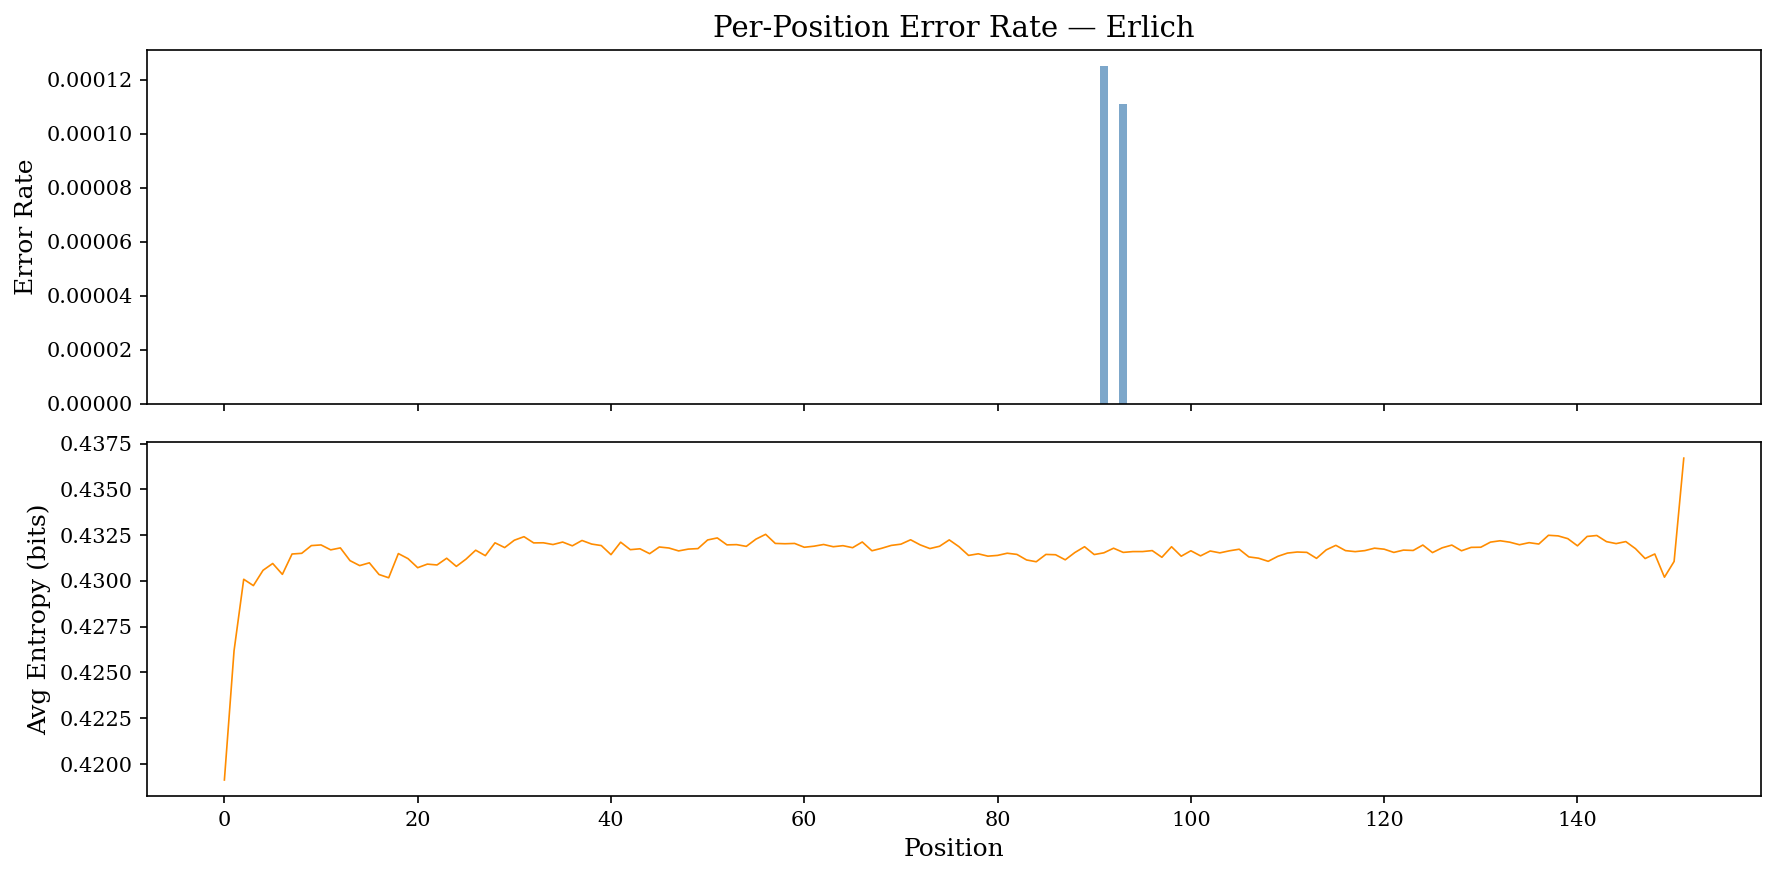

Active: 152 | Mean: 0.000002 | Max: 0.000125 (pos 91)
Boundary (first/last 15): 0.000000 | Middle: 0.000002 | Ratio: 0.00


In [7]:
pos_errors = np.zeros(LABEL_SEQ_LEN, dtype=np.int64)
pos_total  = np.zeros(LABEL_SEQ_LEN, dtype=np.int64)
pos_entropy = np.zeros(LABEL_SEQ_LEN, dtype=np.float64)

for i in range(N):
    pred, label, prob = all_preds[i].numpy(), all_labels[i].numpy(), all_probs[i].numpy()
    for t in range(LABEL_SEQ_LEN):
        if label[t] == PADDING_IDX: break
        pos_total[t] += 1
        if pred[t] != label[t]: pos_errors[t] += 1
        p = np.clip(prob[t, 1:], 1e-10, 1.0); p = p / p.sum()
        pos_entropy[t] += -np.sum(p * np.log2(p))

active = pos_total > 0
error_rate  = np.where(active, pos_errors / pos_total, 0)
entropy_avg = np.where(active, pos_entropy / pos_total, 0)

pd.DataFrame({'position': range(LABEL_SEQ_LEN), 'errors': pos_errors, 'total': pos_total,
              'error_rate': error_rate, 'avg_entropy': entropy_avg}
             ).to_csv(T_RESULTS / f"per_position_errors_{DATASET_NAME}.csv", index=False)

sio.savemat(str(T_MAT / f'theory_perpos_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME, 'positions': np.arange(LABEL_SEQ_LEN, dtype=np.float64),
    'error_rate': error_rate, 'avg_entropy': entropy_avg,
    'errors': pos_errors.astype(np.float64), 'total': pos_total.astype(np.float64),
})

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.bar(range(LABEL_SEQ_LEN), error_rate, color='steelblue', alpha=0.7)
ax1.set_ylabel("Error Rate"); ax1.set_title(f"Per-Position Error Rate — {DATASET_NAME}")
ax2.plot(range(LABEL_SEQ_LEN), entropy_avg, color='darkorange', lw=0.8)
ax2.set_ylabel("Avg Entropy (bits)"); ax2.set_xlabel("Position")
plt.tight_layout(); plt.savefig(T_FIGURES / f"perpos_{DATASET_NAME}.png"); plt.show()

ar = error_rate[active]; L_a = int(active.sum()); bnd = max(1, L_a // 10)
bnd_err = np.concatenate([ar[:bnd], ar[-bnd:]]).mean()
mid_err = ar[bnd:-bnd].mean() if L_a > 2*bnd else 0
print(f"Active: {L_a} | Mean: {ar.mean():.6f} | Max: {ar.max():.6f} (pos {np.argmax(error_rate)})")
print(f"Boundary (first/last {bnd}): {bnd_err:.6f} | Middle: {mid_err:.6f} | Ratio: {bnd_err/mid_err:.2f}" if mid_err > 0 else "")


## Experiment 3: Cluster Size Sensitivity

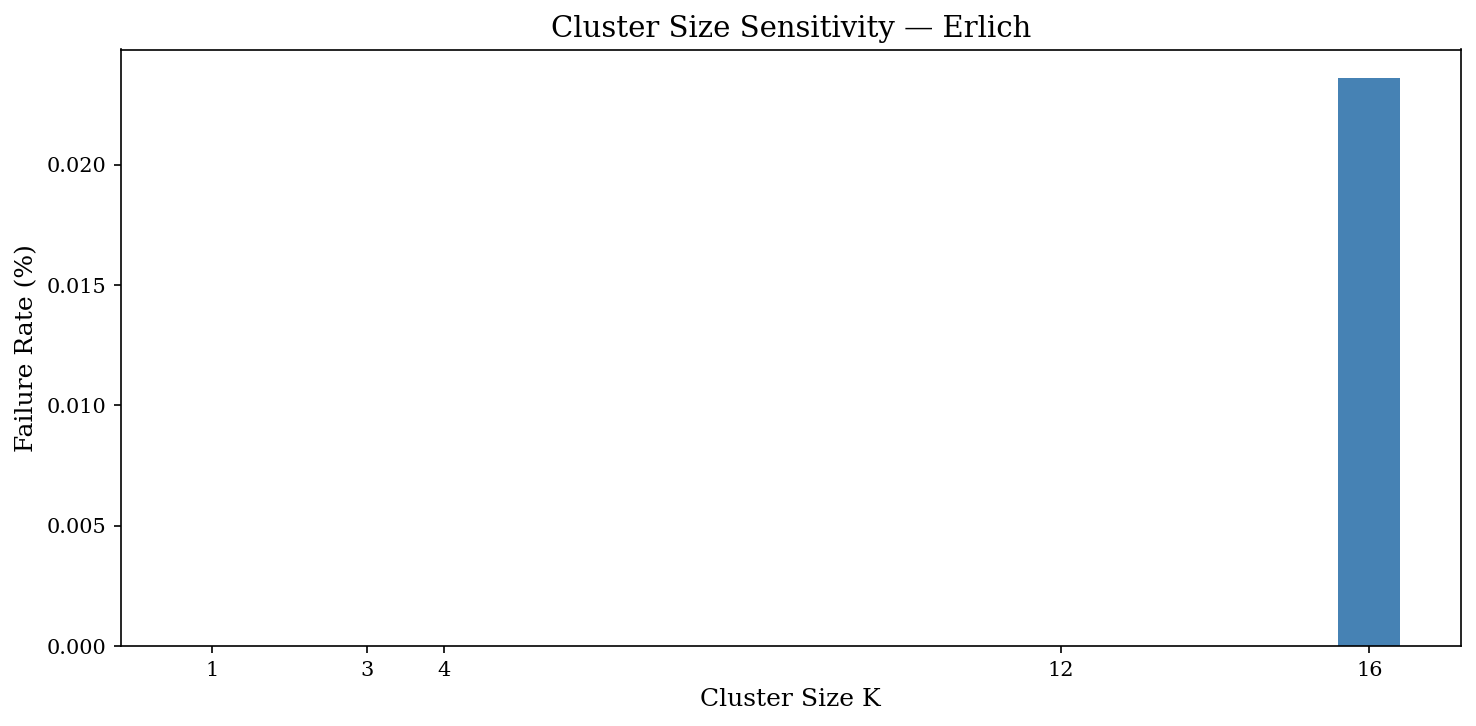

K  | Total    | Failed   | Rate%
 1 |        2 |        0 | 0.0000%
 3 |        1 |        0 | 0.0000%
 4 |        1 |        0 | 0.0000%
12 |        1 |        0 | 0.0000%
16 |    71995 |       17 | 0.0236%


In [8]:
cs = defaultdict(lambda: {'total': 0, 'failed': 0})
for i in range(N):
    k = min(test_ds.get_cluster_size(i), MAX_CLUSTER_SIZE)
    cs[k]['total'] += 1
    if decode_seq(all_preds[i], INT_TO_CHAR) != decode_seq(all_labels[i], INT_TO_CHAR):
        cs[k]['failed'] += 1

ks = sorted(cs.keys())
cs_total  = np.array([cs[k]['total']  for k in ks], dtype=np.float64)
cs_failed = np.array([cs[k]['failed'] for k in ks], dtype=np.float64)
cs_rate   = np.where(cs_total > 0, cs_failed / cs_total * 100, 0)

pd.DataFrame({'cluster_size': ks, 'total': cs_total.astype(int), 'failed': cs_failed.astype(int),
              'failure_rate_pct': cs_rate}).to_csv(T_RESULTS / f"cluster_size_{DATASET_NAME}.csv", index=False)

sio.savemat(str(T_MAT / f'theory_clustersize_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME,
    'cluster_sizes': np.array(ks, dtype=np.float64),
    'cluster_total': cs_total, 'cluster_failed': cs_failed,
    'failure_rate_pct': cs_rate,
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ks, cs_rate, color='steelblue'); ax.set_xlabel("Cluster Size K"); ax.set_ylabel("Failure Rate (%)")
ax.set_title(f"Cluster Size Sensitivity — {DATASET_NAME}"); ax.set_xticks(ks)
plt.tight_layout(); plt.savefig(T_FIGURES / f"clustersize_{DATASET_NAME}.png"); plt.show()

print("K  | Total    | Failed   | Rate%")
for i, k in enumerate(ks):
    print(f"{k:2d} | {int(cs_total[i]):8d} | {int(cs_failed[i]):8d} | {cs_rate[i]:.4f}%")


## Experiment 4: Error Type Breakdown on Failed Clusters

In [9]:
ea = []
for idx in tqdm(dnn_failures, desc="Analyzing failures"):
    ps = decode_seq(all_preds[idx], INT_TO_CHAR)
    ls = decode_seq(all_labels[idx], INT_TO_CHAR)
    ed = edit_distance(ps, ls); lm = len(ps) == len(ls)
    nsub = sum(a != b for a, b in zip(ps, ls)) if lm else -1
    conf = all_probs[idx][:, 1:].max(dim=1).values.mean().item()
    ea.append({'idx': idx, 'edit_dist': ed, 'len_match': lm, 'num_sub': nsub,
               'pred_len': len(ps), 'label_len': len(ls),
               'cluster_size': min(test_ds.get_cluster_size(idx), MAX_CLUSTER_SIZE), 'confidence': conf})

ea_df = pd.DataFrame(ea)
ea_df.to_csv(T_RESULTS / f"error_analysis_{DATASET_NAME}.csv", index=False)

sio.savemat(str(T_MAT / f'theory_errors_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME,
    'edit_distances': np.array(ea_df['edit_dist'].values, dtype=np.float64),
    'num_substitutions': np.array(ea_df['num_sub'].values, dtype=np.float64),
    'cluster_sizes_failed': np.array(ea_df['cluster_size'].values, dtype=np.float64),
    'confidences_failed': np.array(ea_df['confidence'].values, dtype=np.float64),
    'length_match': np.array(ea_df['len_match'].values, dtype=np.float64),
})

print(f"Failures: {len(ea)}")
if ea:
    print(f"\nEdit distance distribution:")
    for v, c in ea_df['edit_dist'].value_counts().sort_index().head(10).items():
        print(f"  ED={v}: {c} ({c/len(ea)*100:.1f}%)")
    lm = ea_df['len_match'].sum()
    print(f"\nPure substitution (len match): {lm}/{len(ea)} ({lm/len(ea)*100:.1f}%)")
    if lm > 0:
        sd = ea_df[ea_df['len_match']]
        print(f"  1 sub: {(sd['num_sub']==1).sum()}, 2 sub: {(sd['num_sub']==2).sum()}, 3+ sub: {(sd['num_sub']>=3).sum()}")
    print(f"\nFailed cluster sizes: mean K={ea_df['cluster_size'].mean():.1f}, "
          f"K≤4: {(ea_df['cluster_size']<=4).sum()} ({(ea_df['cluster_size']<=4).sum()/len(ea)*100:.1f}%)")


Analyzing failures:   0%|          | 0/17 [00:00<?, ?it/s]

Failures: 17

Edit distance distribution:
  ED=1: 17 (100.0%)

Pure substitution (len match): 17/17 (100.0%)
  1 sub: 17, 2 sub: 0, 3+ sub: 0

Failed cluster sizes: mean K=16.0, K≤4: 0 (0.0%)


## Experiment 5: GRU Hidden State Correlation Decay
Measures how fast cosine similarity between hidden states decays with distance.

GRU states:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_2275805/3419035145.py:20: RuntimeWarning: invalid value encountered in divide
  avg_corr = np.where(corr_cnt > 0, corr_sum / corr_cnt, 0)


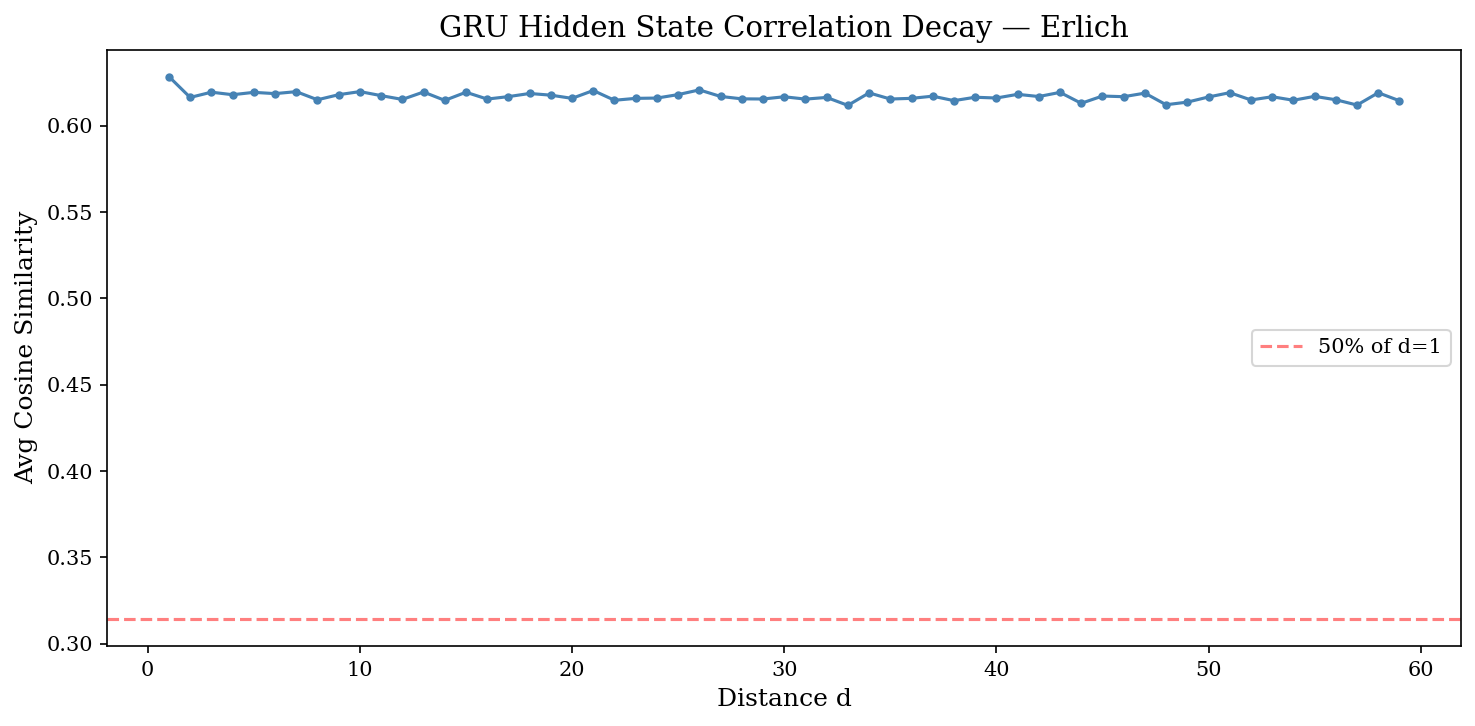

Correlation at d=1: 0.6285
  Drops to 90% at d=152
  Drops to 75% at d=152
  Drops to 50% at d=152
  Drops to 25% at d=152
  Drops to 10% at d=152


In [10]:
N_H = min(100, N)
h_idx = random.sample(range(N), N_H)

gru_outs = []
with torch.no_grad():
    for idx in tqdm(h_idx, desc="GRU states"):
        c, _ = test_ds[idx]
        out = model.forward_with_intermediates(c.unsqueeze(0).to(DEVICE))
        gru_outs.append(out['gru_out'][0].cpu().numpy())

corr_sum = np.zeros(LABEL_SEQ_LEN, dtype=np.float64)
corr_cnt = np.zeros(LABEL_SEQ_LEN, dtype=np.int64)

for g in gru_outs:
    nrm = g / np.clip(np.linalg.norm(g, axis=1, keepdims=True), 1e-8, None)
    for d in range(1, LABEL_SEQ_LEN):
        sims = np.sum(nrm[:-d] * nrm[d:], axis=1)
        corr_sum[d] += sims.sum(); corr_cnt[d] += len(sims)

avg_corr = np.where(corr_cnt > 0, corr_sum / corr_cnt, 0)

decay_dist = {}
for thr in [0.90, 0.75, 0.50, 0.25, 0.10]:
    for d in range(1, LABEL_SEQ_LEN):
        if avg_corr[1] > 0 and avg_corr[d] < thr * avg_corr[1]:
            decay_dist[thr] = d; break
    else: decay_dist[thr] = LABEL_SEQ_LEN

pd.DataFrame({'distance': range(LABEL_SEQ_LEN), 'avg_cosine_sim': avg_corr}).to_csv(
    T_RESULTS / f"gru_corr_decay_{DATASET_NAME}.csv", index=False)
with open(T_RESULTS / f"corr_decay_distances_{DATASET_NAME}.json", 'w') as f:
    json.dump({f"drop_to_{int(k*100)}pct": v for k, v in decay_dist.items()}, f, indent=2)

sio.savemat(str(T_MAT / f'theory_gru_corr_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME,
    'distances': np.arange(LABEL_SEQ_LEN, dtype=np.float64),
    'avg_cosine_similarity': avg_corr,
    'corr_at_d1': np.float64(avg_corr[1]),
    **{f'decay_to_{int(k*100)}pct': np.float64(v) for k, v in decay_dist.items()},
})

fig, ax = plt.subplots(figsize=(10, 5))
dmax = min(60, LABEL_SEQ_LEN)
ax.plot(range(1, dmax), avg_corr[1:dmax], 'o-', ms=3, color='steelblue')
ax.axhline(y=avg_corr[1]*0.5, color='r', ls='--', alpha=0.5, label='50% of d=1')
ax.set_xlabel("Distance d"); ax.set_ylabel("Avg Cosine Similarity")
ax.set_title(f"GRU Hidden State Correlation Decay — {DATASET_NAME}"); ax.legend()
plt.tight_layout(); plt.savefig(T_FIGURES / f"gru_corr_{DATASET_NAME}.png"); plt.show()

print(f"Correlation at d=1: {avg_corr[1]:.4f}")
for thr, d in decay_dist.items(): print(f"  Drops to {thr*100:.0f}% at d={d}")


## Experiment 6: Confidence Score Analysis

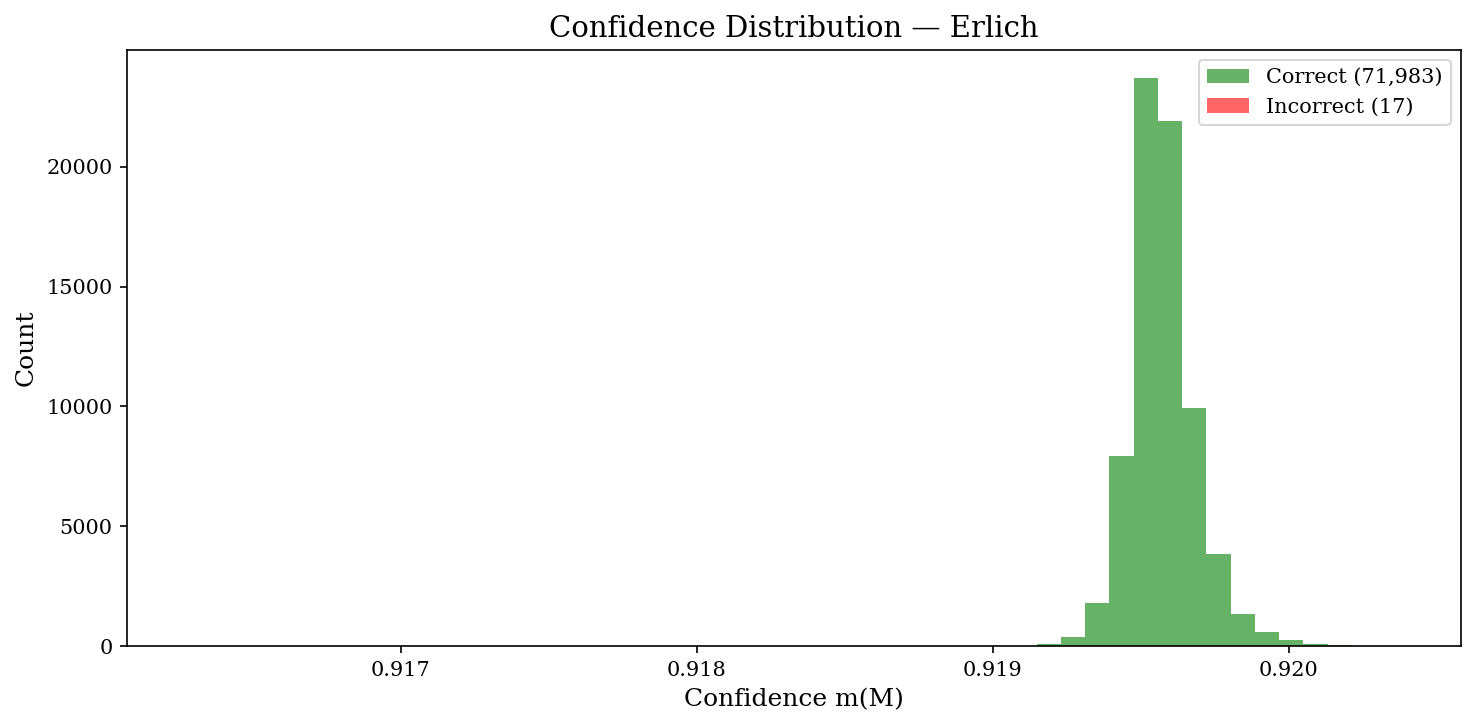

Correct:   mean=0.9196, std=0.0001
Incorrect: mean=0.9196, std=0.0002
Separation: -0.0000


In [11]:
correct_c, incorrect_c = [], []
for i in range(N):
    c = all_probs[i][:, 1:].max(dim=1).values.mean().item()
    (correct_c if decode_seq(all_preds[i], INT_TO_CHAR) == decode_seq(all_labels[i], INT_TO_CHAR) else incorrect_c).append(c)

ca, ia = np.array(correct_c), np.array(incorrect_c) if incorrect_c else np.array([0.0])

sio.savemat(str(T_MAT / f'theory_confidence_{DATASET_NAME}.mat'), {
    'dataset_name': DATASET_NAME,
    'confidence_correct': ca, 'confidence_incorrect': ia,
    'n_correct': np.float64(len(correct_c)), 'n_incorrect': np.float64(len(incorrect_c)),
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ca, bins=50, alpha=0.6, label=f'Correct ({len(correct_c):,})', color='green')
if len(incorrect_c) > 0:
    ax.hist(ia, bins=50, alpha=0.6, label=f'Incorrect ({len(incorrect_c):,})', color='red')
ax.set_xlabel("Confidence m(M)"); ax.set_ylabel("Count")
ax.set_title(f"Confidence Distribution — {DATASET_NAME}"); ax.legend()
plt.tight_layout(); plt.savefig(T_FIGURES / f"confidence_{DATASET_NAME}.png"); plt.show()

print(f"Correct:   mean={ca.mean():.4f}, std={ca.std():.4f}")
print(f"Incorrect: mean={ia.mean():.4f}, std={ia.std():.4f}")
if len(incorrect_c) > 0: print(f"Separation: {ca.mean()-ia.mean():.4f}")


## Summary

In [12]:
summary = {
    "dataset": DATASET_NAME, "total_clusters": N,
    "dnn_failures": len(dnn_failures), "dnn_failure_rate_pct": round(dnn_rate, 4),
    "target_failure_rate_pct": CONFIG["target_failure"],
    "label_seq_len": LABEL_SEQ_LEN, "model_params": sum(p.numel() for p in model.parameters()),
    "context_radius": cr_summary,
    "correlation_decay": {f"drop_to_{int(k*100)}pct": v for k, v in decay_dist.items()},
}
with open(T_RESULTS / f"summary_{DATASET_NAME}.json", 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\n{'='*60}")
print(f"COMPLETE: {DATASET_NAME}")
print(f"{'='*60}")
print(json.dumps(summary, indent=2))
print(f"\nOutputs in: {THEORY_DIR}")
for sub in [T_RESULTS, T_MAT, T_FIGURES]:
    print(f"\n  {sub.name}/")
    for f in sorted(sub.iterdir()): print(f"    {f.name:50s} {f.stat().st_size:>10,} bytes")



COMPLETE: Erlich
{
  "dataset": "Erlich",
  "total_clusters": 72000,
  "dnn_failures": 17,
  "dnn_failure_rate_pct": 0.0236,
  "target_failure_rate_pct": 0.02,
  "label_seq_len": 152,
  "model_params": 3480949,
  "context_radius": {
    "pct50": {
      "mean": 1.0588235294117647,
      "median": 1.0,
      "max": 2
    },
    "pct75": {
      "mean": 2.1176470588235294,
      "median": 2.0,
      "max": 3
    },
    "pct90": {
      "mean": 4.823529411764706,
      "median": 5.0,
      "max": 5
    },
    "pct95": {
      "mean": 8.235294117647058,
      "median": 9.0,
      "max": 9
    },
    "pct99": {
      "mean": 18.529411764705884,
      "median": 20.0,
      "max": 21
    }
  },
  "correlation_decay": {
    "drop_to_90pct": 152,
    "drop_to_75pct": 152,
    "drop_to_50pct": 152,
    "drop_to_25pct": 152,
    "drop_to_10pct": 152
  }
}

Outputs in: Experiments/Erlich_v4/TheoryAnalysis

  Results/
    cluster_size_Erlich.csv                                   117 bytes
    cont